# Toy Inference From Run Directory

Interactive notebook version for continuing development.

Workflow:
1. Set `RUN_DIR` and toy physical inputs.
2. Load `train_config_used.json`, `scaler_state.json`, and checkpoint.
3. Build scaled toy features.
4. Run inference and plot mean plus `+/- 1 std`.

In [8]:
from pathlib import Path

import json
import sys
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


In [9]:
# User config
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "MLP").exists() and PROJECT_ROOT.name == "MLP":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Archived stage-1/stage-2 runs are self-contained and can leave BASE_RUN_DIR = None.
# Refinement runs (for example distill_cdf_onset_*) reuse the teacher run's scaler/config,
# so point BASE_RUN_DIR to that archived run.
BASE_RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "stage2_NLL_penetration_20260317_194155"

# RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "stage2_NLL_penetration_20260317_194155"

# RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "distill_cdf_onset_20260331_171132"

RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "distill_cdf_onset_20260331_194213"

toy_raw = {
    "tilt_angle_radian": float(np.deg2rad(20.0)),
    "plumes": 10.0,
    "diameter_mm": 0.355,
    "injection_duration_us": 800.0,
    "injection_pressure_bar": 2000.0,
    "chamber_pressure_bar": 15.0,
    "control_backpressure_bar": 4.0,
}

toy_n_points = 300
toy_time_ms = np.linspace(0.0, 5.0, toy_n_points, dtype=np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [10]:


# 2D solver Macro 
t = 0.85 # ms
cone_angle = 20 # deg, change to a function in the future

cylinder_radius = 120 # mm
cylinder_height = 60 # mm

right_padding = 10 # mm
piston_height = 30 # mm

grid_size = 0.1 # mm

cylinder_head_offset = 50 # mm, improve to parametrized function later

assert cylinder_head_offset <= cylinder_height

# Keep mm -> grid conversion stable when grid_size is fractional (for example 0.1 mm).
def mm_to_grid_index(value_mm: float, mode: str = "round") -> int:
    scaled = float(value_mm) / float(grid_size)
    if mode == "round":
        return int(np.rint(scaled))
    if mode == "floor":
        return int(np.floor(scaled + 1e-9))
    if mode == "ceil":
        return int(np.ceil(scaled - 1e-9))
    raise ValueError(f"Unsupported mode: {mode!r}")

grid_width_px = mm_to_grid_index(cylinder_radius + right_padding)

# The canvas must cover the largest y coordinate used by the geometry.
grid_height_mm = cylinder_head_offset + cylinder_height
grid_height_px = mm_to_grid_index(grid_height_mm)


In [11]:

x = np.arange(grid_width_px, dtype=float) * grid_size
y = np.arange(grid_height_px, dtype=float) * grid_size

X, Y = np.meshgrid(x, y, indexing="xy")


In [12]:
def make_activation(name: str) -> nn.Module:
    name = (name or "relu").lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation '{name}'")


class PenetrationMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        *,
        activation: str = "relu",
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    make_activation(activation),
                ]
            )
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def split_model_outputs(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None]:
    if model_output.shape[-1] < 2:
        raise ValueError(f"Expected at least 2 outputs, got shape {tuple(model_output.shape)}")
    mu = model_output[..., :1]
    log_var = model_output[..., 1:2]
    onset_logit = model_output[..., 2:3] if model_output.shape[-1] >= 3 else None
    return mu, log_var, onset_logit


def split_mu_logvar(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    mu, log_var, _ = split_model_outputs(model_output)
    return mu, log_var


def resolve_model_path(run_dir: Path) -> Path:
    for name in ("best_model_refinement.pt", "best_model_stage2.pt", "best_model_stage1.pt"):
        model_path = run_dir / name
        if model_path.exists():
            return model_path
    raise FileNotFoundError(f"No supported model checkpoint found under: {run_dir}")


def unwrap_state_dict(state: Any) -> dict[str, torch.Tensor]:
    if isinstance(state, dict):
        for key in ("state_dict", "model_state_dict"):
            if key in state and isinstance(state[key], dict):
                return state[key]
    return state


def infer_output_dim_from_state(state_dict: dict[str, torch.Tensor]) -> int:
    weight_keys = [key for key, value in state_dict.items() if key.endswith("weight") and getattr(value, "ndim", None) == 2]
    if not weight_keys:
        raise KeyError("Could not infer output dimension from checkpoint state dict.")
    final_weight = state_dict[weight_keys[-1]]
    return int(final_weight.shape[0])


def resolve_run_artifacts(run_dir: Path, base_run_dir: Path | None = None) -> dict[str, Path | None]:
    model_path = resolve_model_path(run_dir)
    config_path = run_dir / "train_config_used.json"
    scaler_path = run_dir / "scaler_state.json"
    refine_config_path = run_dir / "refine_config.json"

    if config_path.exists() and scaler_path.exists():
        metadata_run_dir = run_dir
        run_kind = "archived"
    elif refine_config_path.exists():
        if base_run_dir is None:
            raise FileNotFoundError(
                "This refinement run does not contain train_config_used.json / scaler_state.json. "
                "Set BASE_RUN_DIR to the archived teacher run used to initialize refinement."
            )
        metadata_run_dir = base_run_dir
        config_path = metadata_run_dir / "train_config_used.json"
        scaler_path = metadata_run_dir / "scaler_state.json"
        if not config_path.exists() or not scaler_path.exists():
            raise FileNotFoundError(
                f"BASE_RUN_DIR is missing required metadata files: {metadata_run_dir}"
            )
        run_kind = "refinement"
    else:
        raise FileNotFoundError(
            f"Could not resolve metadata files under {run_dir}. "
            "Expected archived train_config_used.json/scaler_state.json or refine_config.json."
        )

    return {
        "run_dir": run_dir,
        "model_path": model_path,
        "config_path": config_path,
        "scaler_path": scaler_path,
        "refine_config_path": refine_config_path if refine_config_path.exists() else None,
        "metadata_run_dir": metadata_run_dir,
        "run_kind": run_kind,
    }


def zscore_from_state(value: float, z_col: str, scaler_state: dict[str, Any]) -> float:
    stats = scaler_state["zscore"][z_col]
    return (float(value) - float(stats["mean"])) / (float(stats["std"]) + 1e-12)


def build_toy_feature_matrix(
    raw: dict[str, float],
    time_ms: np.ndarray | float,
    scaler_state: dict[str, Any],
    feature_columns: list[str],
    time_feature: str,
) -> np.ndarray:
    p_inj = float(raw["injection_pressure_bar"])
    p_ch = float(raw["chamber_pressure_bar"])
    delta_p = max(p_inj - p_ch, 1e-6)

    time_ms_arr = np.asarray(time_ms, dtype=np.float32)
    scalar_input = time_ms_arr.ndim == 0
    if scalar_input:
        time_ms_arr = time_ms_arr.reshape(1)

    time_min_ms = float(scaler_state["time"]["min_ms"])
    time_max_ms = float(scaler_state["time"]["max_ms"])
    time_span_ms = max(time_max_ms - time_min_ms, 1e-12)
    time_norm = np.clip((time_ms_arr - time_min_ms) / time_span_ms, 0.0, 1.0).astype(np.float32)

    feature_series: dict[str, np.ndarray] = {
        time_feature: time_norm,
        "tilt_angle_radian_z": np.full_like(
            time_norm,
            zscore_from_state(raw["tilt_angle_radian"], "tilt_angle_radian_z", scaler_state),
            dtype=np.float32,
        ),
        "plumes_z": np.full_like(
            time_norm,
            zscore_from_state(raw["plumes"], "plumes_z", scaler_state),
            dtype=np.float32,
        ),
        "diameter_mm_z": np.full_like(
            time_norm,
            zscore_from_state(raw["diameter_mm"], "diameter_mm_z", scaler_state),
            dtype=np.float32,
        ),
        "injection_duration_us_z": np.full_like(
            time_norm,
            zscore_from_state(raw["injection_duration_us"], "injection_duration_us_z", scaler_state),
            dtype=np.float32,
        ),
        "log_injection_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(p_inj), "log_injection_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "log_chamber_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(max(p_ch, 1e-6)), "log_chamber_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "log_delta_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(delta_p), "log_delta_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "control_backpressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(raw["control_backpressure_bar"], "control_backpressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
    }

    columns: list[np.ndarray] = []
    for name in feature_columns:
        if name not in feature_series:
            raise KeyError(f"Unsupported feature column in config: {name}")
        columns.append(feature_series[name])
    features = np.column_stack(columns).astype(np.float32)
    if scalar_input:
        return features
    return features


In [13]:
artifacts = resolve_run_artifacts(RUN_DIR, base_run_dir=BASE_RUN_DIR)
config_path = artifacts["config_path"]
scaler_path = artifacts["scaler_path"]
model_path = artifacts["model_path"]
refine_config_path = artifacts["refine_config_path"]

with config_path.open("r", encoding="utf-8") as f:
    train_config = json.load(f)
with scaler_path.open("r", encoding="utf-8") as f:
    scaler_state = json.load(f)

refine_config = None
if refine_config_path is not None:
    with refine_config_path.open("r", encoding="utf-8") as f:
        refine_config = json.load(f)

feature_columns = list(train_config["feature_columns"])
time_feature = str(train_config.get("time_feature", "time_norm_0_5ms"))

state = torch.load(model_path, map_location=DEVICE)
state_dict = unwrap_state_dict(state)
output_dim = infer_output_dim_from_state(state_dict)

model = PenetrationMLP(
    input_dim=int(train_config["input_dim"]),
    hidden_dims=[int(x) for x in train_config["hidden_dims"]],
    output_dim=output_dim,
    activation=str(train_config.get("activation", "relu")),
    dropout=float(train_config.get("dropout", 0.0)),
)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

HAS_ONSET_HEAD = output_dim >= 3

mlp_module_dir = PROJECT_ROOT / "MLP"
if str(mlp_module_dir) not in sys.path:
    sys.path.insert(0, str(mlp_module_dir))

try:
    from v1_direct_feature_training.ood_sanity import concise_warning_text, format_sanity_report, load_cdf_empirical_support, check_input_sanity
except ModuleNotFoundError:
    from ood_sanity import concise_warning_text, format_sanity_report, load_cdf_empirical_support, check_input_sanity

support = load_cdf_empirical_support(PROJECT_ROOT, split_filter="clean")
sanity_report = check_input_sanity(toy_raw, support)
sanity_warning_text = concise_warning_text(sanity_report, max_lines=4)

print(format_sanity_report(sanity_report))


print(f"RUN_DIR: {RUN_DIR.resolve()}")
print(f"Run kind: {artifacts['run_kind']}")
print(f"Metadata source: {Path(artifacts['metadata_run_dir']).resolve()}")
print(f"Model checkpoint: {Path(model_path).name}")
print(f"Device: {DEVICE}")
print(f"Feature dimension: {len(feature_columns)}")
print(f"Output dimension: {output_dim}")
print(f"Onset head enabled: {HAS_ONSET_HEAD}")
if refine_config is not None:
    print("Refinement config detected:", refine_config_path.name)


Sanity check severity: ok
OOD warning: False
Exact combo match: True
Support source: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\figures\fit_bias_audit_cdf\cdf_plume_audit.csv
Nearest seen conditions:
- injection_pressure_bar=2000, chamber_pressure_bar=15, control_backpressure_bar=4 (distance=0.000)
- injection_pressure_bar=2000, chamber_pressure_bar=10, control_backpressure_bar=4 (distance=0.436)
- injection_pressure_bar=2200, chamber_pressure_bar=15, control_backpressure_bar=4 (distance=0.596)
RUN_DIR: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\distill_cdf_onset_20260331_194213
Run kind: refinement
Metadata source: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage2_NLL_penetration_20260317_194155
Model checkpoint: best_model_refinement.pt
Device: cuda
Feature dimension: 9
Output dimension: 3
Onset head enabled: True
Refinement config detected: refine_config.json


In [14]:
toy_features_np = build_toy_feature_matrix(
    raw=toy_raw,
    time_ms=toy_time_ms,
    scaler_state=scaler_state,
    feature_columns=feature_columns,
    time_feature=time_feature,
)
toy_features = torch.as_tensor(toy_features_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    toy_out = model(toy_features)
    toy_mu, toy_log_var, toy_onset_logit = split_model_outputs(toy_out)

toy_mu_np = toy_mu.detach().cpu().numpy().reshape(-1)
toy_log_var_np = toy_log_var.detach().cpu().numpy().reshape(-1)
std_floor = float(train_config.get("std_clamp_min", 0.0))
toy_std_np = np.maximum(np.sqrt(np.exp(toy_log_var_np)), std_floor)
toy_upper_np = toy_mu_np + toy_std_np
toy_lower_np = toy_mu_np - toy_std_np
toy_onset_prob_np = None
if toy_onset_logit is not None:
    toy_onset_prob_np = torch.sigmoid(toy_onset_logit).detach().cpu().numpy().reshape(-1)

print("Toy inference completed with feature shape:", toy_features_np.shape)
print("Expected feature dimension:", len(feature_columns))
print("Predicted std range:", float(np.min(toy_std_np)), float(np.max(toy_std_np)))
if toy_onset_prob_np is not None:
    print("Predicted onset probability range:", float(np.min(toy_onset_prob_np)), float(np.max(toy_onset_prob_np)))


Toy inference completed with feature shape: (300, 9)
Expected feature dimension: 9
Predicted std range: 7.658609867095947 57.99283218383789
Predicted onset probability range: 0.6575286388397217 0.9819819331169128


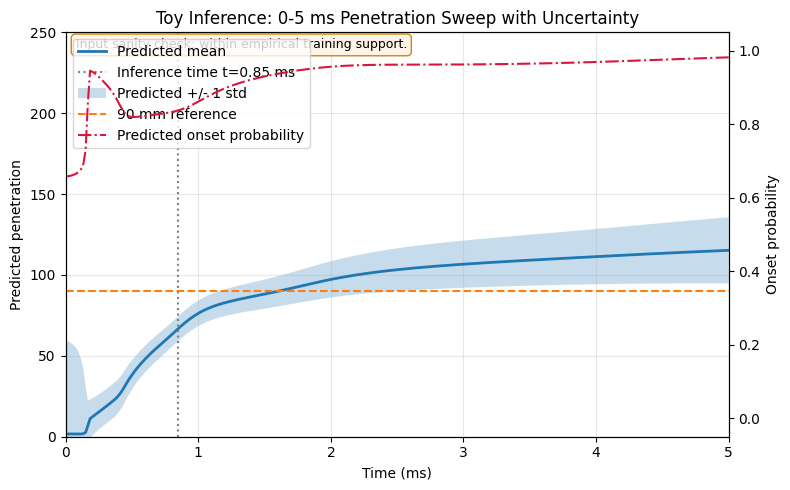

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(toy_time_ms, toy_mu_np, linewidth=2, label="Predicted mean")
ax.axvline(t, color="gray", linestyle=":", label=f"Inference time t={t} ms")
ax.fill_between(toy_time_ms, toy_lower_np, toy_upper_np, alpha=0.25, label="Predicted +/- 1 std")
ax.plot(toy_time_ms, 90 * np.ones_like(toy_time_ms), linestyle="--", label="90 mm reference")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Predicted penetration")
title = "Toy Inference: 0-5 ms Penetration Sweep with Uncertainty"
if sanity_report["is_ood"]:
    title += "\nEmpirical-support warning: OOD / weakly supported input"
ax.set_title(title)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 250)
ax.set_xlim(0, 5)

if toy_onset_prob_np is not None:
    ax_onset = ax.twinx()
    ax_onset.plot(
        toy_time_ms,
        toy_onset_prob_np,
        color="crimson",
        linestyle="-.",
        linewidth=1.5,
        label="Predicted onset probability",
    )
    ax_onset.set_ylabel("Onset probability")
    ax_onset.set_ylim(-0.05, 1.05)
    handles_left, labels_left = ax.get_legend_handles_labels()
    handles_right, labels_right = ax_onset.get_legend_handles_labels()
    ax.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")
else:
    ax.legend()

bbox_props = dict(boxstyle="round,pad=0.35", facecolor="#fff4e5", edgecolor="#cc7a00", alpha=0.92)
ax.text(
    0.015,
    0.985,
    sanity_warning_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=bbox_props,
)

plt.tight_layout()
plt.show()


In [16]:
# ========================================
# Calculate the penetration and log variance at a certain time point
# ========================================
toy_features_np = build_toy_feature_matrix(
    raw=toy_raw,
    time_ms=t, # given time
    scaler_state=scaler_state,
    feature_columns=feature_columns,
    time_feature=time_feature,
)

toy_features = torch.as_tensor(toy_features_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    toy_out = model(toy_features)
    toy_mu, toy_log_var, toy_onset_logit = split_model_outputs(toy_out)

toy_mu_np = toy_mu.detach().cpu().numpy().reshape(-1)
toy_log_var_np = toy_log_var.detach().cpu().numpy().reshape(-1)
std_floor = float(train_config.get("std_clamp_min", 0.0))
toy_std_np = np.maximum(np.sqrt(np.exp(toy_log_var_np)), std_floor)
toy_upper_np = toy_mu_np + toy_std_np
toy_lower_np = toy_mu_np - toy_std_np
toy_onset_prob_np = None
if toy_onset_logit is not None:
    toy_onset_prob_np = torch.sigmoid(toy_onset_logit).detach().cpu().numpy().reshape(-1)

print(f"Predicted penetration mean at t={t} ms:", float(toy_mu_np.item()))
print(f"Predicted penetration std at t={t} ms:", float(toy_std_np.item()))
if toy_onset_prob_np is not None:
    print(f"Predicted onset probability at t={t} ms:", float(toy_onset_prob_np.item()))


Predicted penetration mean at t=0.85 ms: 66.90352630615234
Predicted penetration std at t=0.85 ms: 7.676878452301025
Predicted onset probability at t=0.85 ms: 0.837730348110199


## Gradient Stability Diagnostics

These cells turn the current toy inference notebook into a support-aware stability probe for sparse sweeps.

Read the outputs in this order:
1. Check whether the current pressure triplet is actually observed in the clean support table.
2. Inspect the diameter-by-pressure crosstab to see where continuous diameter sweeps are really just interpolation between a few sparse levels.
3. Use the 1D plots plus the metric tables to judge monotonicity violations, gradient sign flips, relative total variation, and curvature spikes.
4. Use the 2D pressure heatmap to see whether `Pinj` / `Pch` coupling is smooth or fragmented around the current anchor.

In [17]:
from IPython.display import display

from gradient_stability_diagnostics import (
    GradientStabilityContext,
    collect_multi_time_metrics,
    current_time_metrics_dataframe,
    diameter_support_crosstab,
    has_exact_pressure_combo,
    load_analysis_support_df,
    nearest_observed_pressure_combo,
    observed_pressure_points_for_backpressure,
    plot_1d_sweep_diagnostics,
    plot_pressure_heatmap,
    pressure_coupling_heatmap,
    sweep_axis_diagnostics,
)

analysis_anchor_raw = {key: float(value) for key, value in toy_raw.items()}
analysis_time_ms = float(t)
analysis_times_ms = [0.5, 1.0, 2.0, 3.5]
analysis_axes = ["injection_pressure_bar", "chamber_pressure_bar", "diameter_mm"]
expected_gradient_sign = {
    "injection_pressure_bar": +1.0,
    "chamber_pressure_bar": -1.0,
    "diameter_mm": +1.0,
}
sweep_points_1d = 61
heatmap_points_2d = 25

analysis_support_df = load_analysis_support_df(support)
diag_ctx = GradientStabilityContext(
    model=model,
    scaler_state=scaler_state,
    feature_columns=feature_columns,
    time_feature=time_feature,
    train_config=train_config,
    support=support,
    support_df=analysis_support_df,
    device=DEVICE,
)

exact_combo_observed = has_exact_pressure_combo(diag_ctx, analysis_anchor_raw)
nearest_combo, nearest_combo_distance = nearest_observed_pressure_combo(diag_ctx, analysis_anchor_raw)

print("Analysis anchor:")
print(json.dumps(analysis_anchor_raw, indent=2))
print(f"Exact observed pressure triplet: {exact_combo_observed}")
print(f"Nearest observed pressure triplet: {nearest_combo} (normalized distance={nearest_combo_distance:.3f})")
print()
print("Observed diameter support counts by pressure triplet:")
display(diameter_support_crosstab(diag_ctx))


Analysis anchor:
{
  "tilt_angle_radian": 0.3490658503988659,
  "plumes": 10.0,
  "diameter_mm": 0.355,
  "injection_duration_us": 800.0,
  "injection_pressure_bar": 2000.0,
  "chamber_pressure_bar": 15.0,
  "control_backpressure_bar": 4.0
}
Exact observed pressure triplet: True
Nearest observed pressure triplet: {'injection_pressure_bar': 2000, 'chamber_pressure_bar': 15, 'control_backpressure_bar': 4} (normalized distance=0.000)

Observed diameter support counts by pressure triplet:


injection_pressure_bar   1400                 1600           2000            \
chamber_pressure_bar       5    10   15   35    5    10   35   5    10   15   
control_backpressure_bar    1    4    1    1     1    4    1    4    4    4   
diameter_mm                                                                   
0.333                       0    0    0    0     0    0    0  306  290  239   
0.348                       0    0    0    0     0    0    0  408  460  417   
0.355                       0    0    0    0     0    0    0  386  400  409   
0.365                       0    0    0    0     0    0    0  872  836  863   
0.375                       0  505    0    0     0  530    0  346  487  581   
0.384                     943    0  923  919  1048    0  894  373  383  382   

injection_pressure_bar    2200                                    
chamber_pressure_bar        5          15         25    35        
control_backpressure_bar     1    4     1     4    1     1     4  
diameter_mm                                                       
0.333                        0    0     0     0    0     0     0  
0.348                        0    0     0     0    0     0     0  
0.355                        0    0     0     0    0     0     0  
0.365                        0    0     0     0    0     0     0  
0.375                        0    0     0     0    0     0     0  
0.384                     1059  897  1079  1148  987  1150  1155

Current-time sweep diagnostics:


,time_ms,anchor_value,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95,curvature_abs_max,mu_range,std_range
axis,,,,,,,,,,,,
injection_pressure_bar,0.85,2000.000,2,1,0.1639,4.3196,0.6137,0.6177,2.870000e-02,6.080000e-02,69.6553,59.4589
chamber_pressure_bar,0.85,15.000,3,0,0.0000,3.7621,0.0489,2.4994,3.052000e-01,8.053000e-01,37.6112,2.7826
diameter_mm,0.85,0.355,6,6,0.4262,63637.5929,0.6459,8290.6084,1.226640e+07,3.350250e+07,66.6078,60.3717



Multi-time stability summary:


,axis,time_ms,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95
0,injection_pressure_bar,0.5,2,1,0.1803,0.4286,0.4169,2.060000e-02
1,chamber_pressure_bar,0.5,3,0,0.0000,0.0569,2.0689,3.470000e-01
2,diameter_mm,0.5,6,4,0.3279,0.3526,4753.4604,2.678130e+06
3,injection_pressure_bar,1.0,2,1,0.1475,0.5839,0.5766,3.430000e-02
4,chamber_pressure_bar,1.0,3,0,0.0000,0.0684,4.1219,1.147400e+00
5,diameter_mm,1.0,6,4,0.4262,0.8035,5137.5820,7.132224e+06
6,injection_pressure_bar,2.0,2,1,0.1311,0.2260,0.1419,6.800000e-03
7,chamber_pressure_bar,2.0,3,0,0.0000,0.0409,2.6380,2.909000e-01
8,diameter_mm,2.0,6,4,0.2623,0.6237,13430.0205,1.308790e+07
9,injection_pressure_bar,3.5,2,1,0.1148,0.0983,0.1256,1.400000e-03


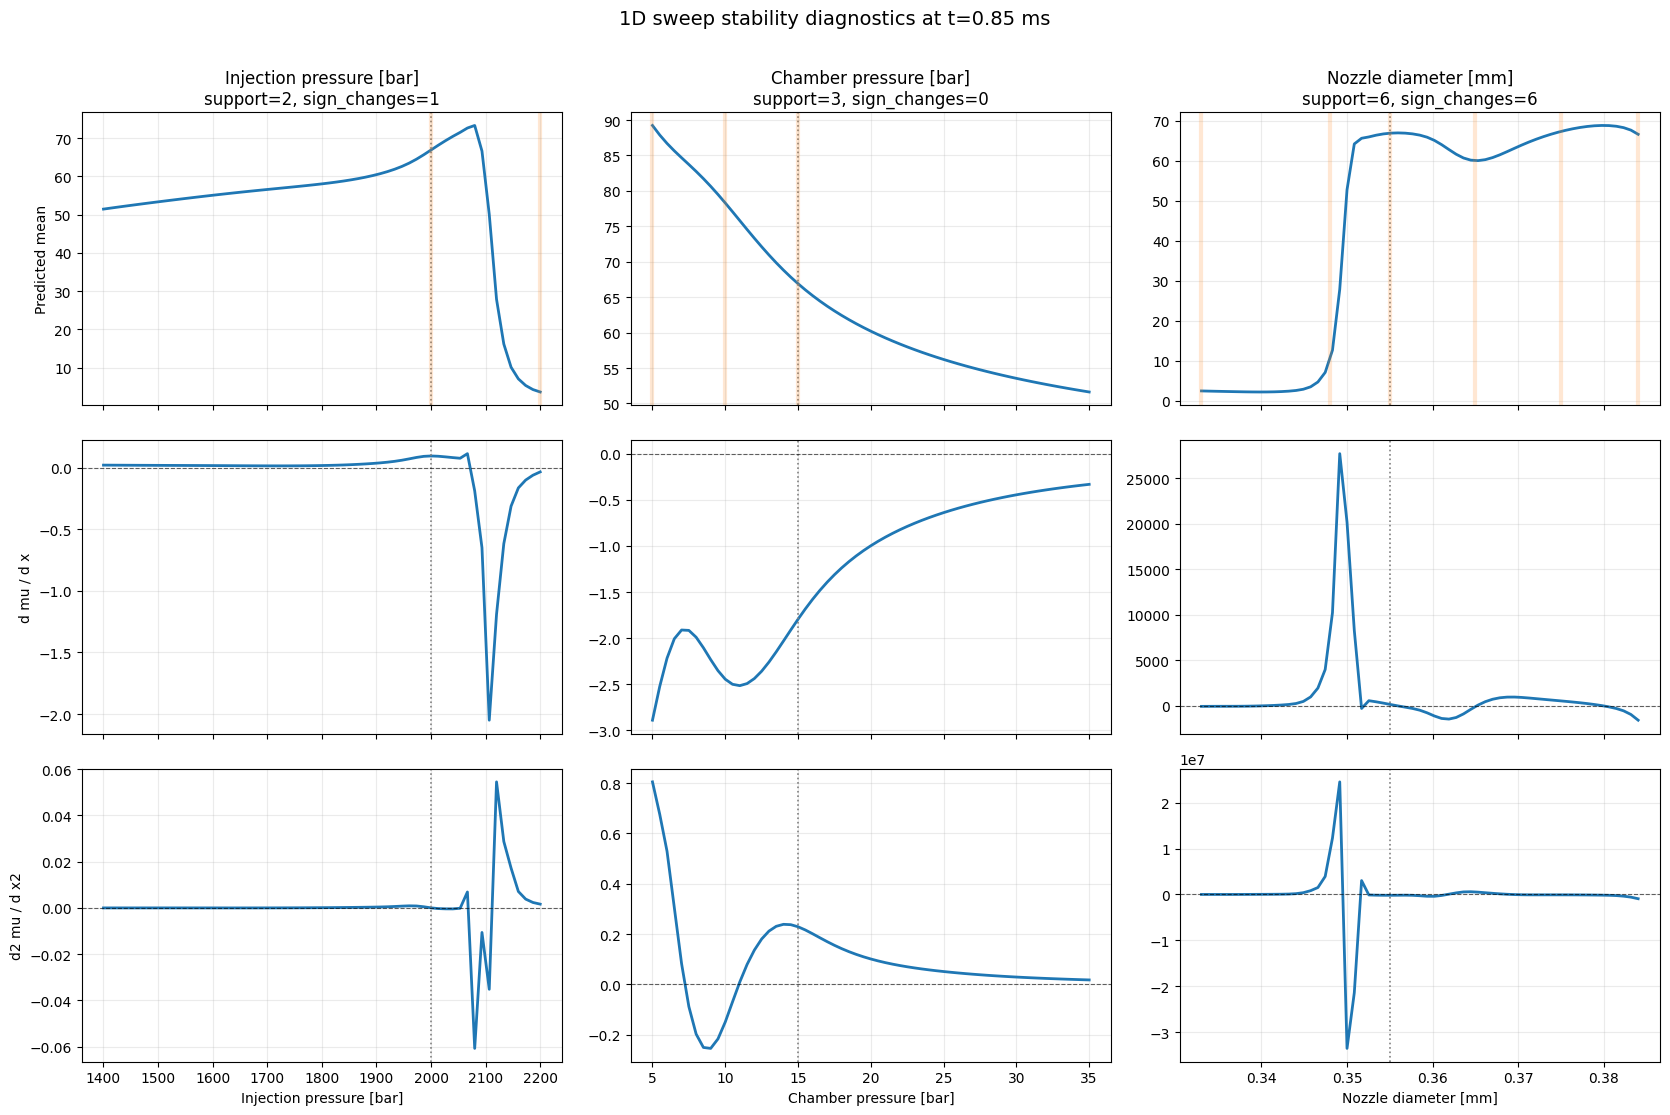

In [18]:
current_time_results = {
    axis_name: sweep_axis_diagnostics(
        diag_ctx,
        axis_name,
        analysis_anchor_raw,
        time_ms_value=analysis_time_ms,
        expected_sign=expected_gradient_sign.get(axis_name),
        n_points=sweep_points_1d,
    )
    for axis_name in analysis_axes
}

current_time_metrics_df = current_time_metrics_dataframe(
    current_time_results,
    analysis_time_ms=analysis_time_ms,
)
multi_time_metrics_df = collect_multi_time_metrics(
    diag_ctx,
    analysis_axes,
    analysis_anchor_raw,
    analysis_times_ms,
    expected_gradient_sign,
    n_points=sweep_points_1d,
)

print("Current-time sweep diagnostics:")
display(current_time_metrics_df.round(4))

print()
print("Multi-time stability summary:")
display(
    multi_time_metrics_df.loc[:, [
        "axis",
        "time_ms",
        "support_levels_on_slice",
        "sign_changes",
        "monotonicity_violation_rate",
        "grad_total_variation_rel",
        "grad_abs_p95",
        "curvature_abs_p95",
    ]].round(4)
)

plot_1d_sweep_diagnostics(
    current_time_results,
    analysis_axes,
    analysis_time_ms=analysis_time_ms,
)
plt.show()


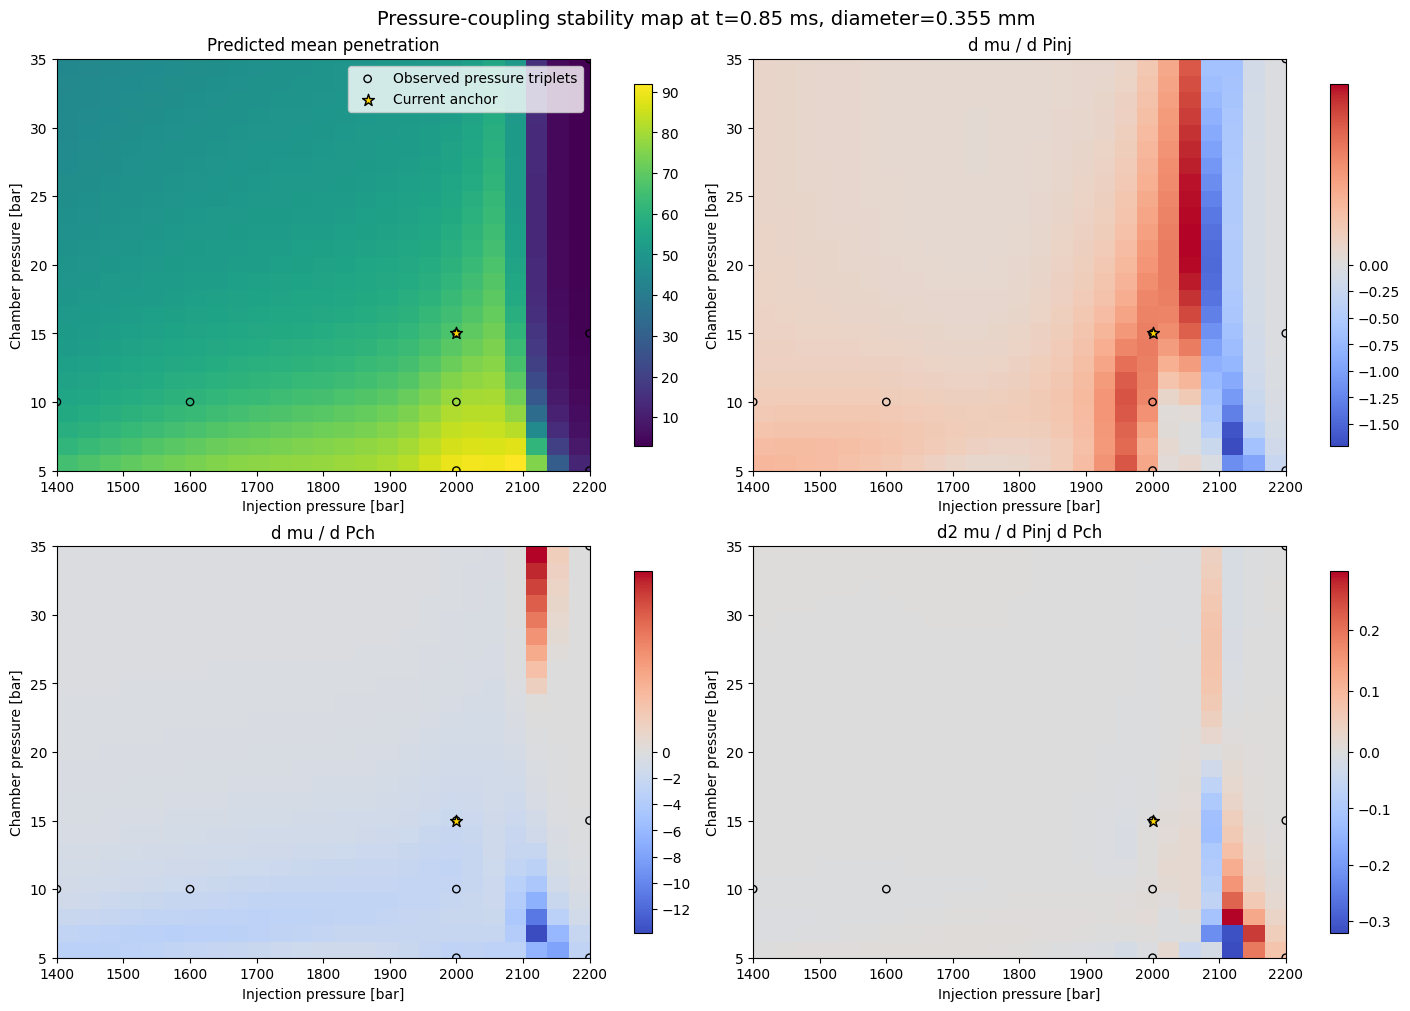

In [19]:
pressure_heatmap = pressure_coupling_heatmap(
    diag_ctx,
    analysis_anchor_raw,
    time_ms_value=analysis_time_ms,
    n_points=heatmap_points_2d,
)
observed_pressure_points = observed_pressure_points_for_backpressure(
    diag_ctx,
    analysis_anchor_raw["control_backpressure_bar"],
)

plot_pressure_heatmap(
    pressure_heatmap,
    observed_pressure_points,
    analysis_anchor_raw,
    analysis_time_ms=analysis_time_ms,
)
plt.show()


## Sparse-Feature Case Study: Diameter and Injection Pressure

This section narrows the argument to the two sparsest continuous features: `diameter_mm` and `injection_pressure_bar`.

The slice choices are support-aware rather than arbitrary:
- Diameter family: only `(Pinj=2000, CB=4, Pch in {5, 10, 15})` contains all six observed diameter levels.
- Injection-pressure family: to keep diameter fixed while still having multiple observed pressure levels, use `(CB=1, diameter=0.384, Pch in {5, 15, 35})`.

The goal is to contrast what the data actually support (a few observed levels) against the dense continuous curve and gradient field invented by the MLP between those levels.

In [20]:
from gradient_stability_diagnostics import (
    collect_sparse_family_time_metrics,
    plot_sparse_family_interpolants,
    plot_sparse_family_time_metrics,
    plot_sparse_feature_support_topology,
)

sparse_focus_time_ms = float(analysis_time_ms)
sparse_focus_times_ms = sorted({0.5, float(analysis_time_ms), 1.0, 2.0, 3.5})

sparse_base_raw = dict(analysis_anchor_raw)
sparse_base_raw.update({
    "diameter_mm": 0.384,
    "injection_pressure_bar": 2000.0,
    "chamber_pressure_bar": 15.0,
    "control_backpressure_bar": 4.0,
})

diameter_family_specs = [
    {
        "label": "Pinj=2000, Pch=5, CB=4",
        "overrides": {
            "injection_pressure_bar": 2000.0,
            "chamber_pressure_bar": 5.0,
            "control_backpressure_bar": 4.0,
        },
    },
    {
        "label": "Pinj=2000, Pch=10, CB=4",
        "overrides": {
            "injection_pressure_bar": 2000.0,
            "chamber_pressure_bar": 10.0,
            "control_backpressure_bar": 4.0,
        },
    },
    {
        "label": "Pinj=2000, Pch=15, CB=4",
        "overrides": {
            "injection_pressure_bar": 2000.0,
            "chamber_pressure_bar": 15.0,
            "control_backpressure_bar": 4.0,
        },
    },
]

injection_family_specs = [
    {
        "label": "Pch=5, CB=1, d=0.384",
        "overrides": {
            "chamber_pressure_bar": 5.0,
            "control_backpressure_bar": 1.0,
            "diameter_mm": 0.384,
        },
    },
    {
        "label": "Pch=15, CB=1, d=0.384",
        "overrides": {
            "chamber_pressure_bar": 15.0,
            "control_backpressure_bar": 1.0,
            "diameter_mm": 0.384,
        },
    },
    {
        "label": "Pch=35, CB=1, d=0.384",
        "overrides": {
            "chamber_pressure_bar": 35.0,
            "control_backpressure_bar": 1.0,
            "diameter_mm": 0.384,
        },
    },
]

print(f"Sparse-feature focus time: {sparse_focus_time_ms:.2f} ms")
print("Diameter family slices:")
print(json.dumps(diameter_family_specs, indent=2))
print()
print("Injection-pressure family slices:")
print(json.dumps(injection_family_specs, indent=2))


Sparse-feature focus time: 0.85 ms
Diameter family slices:
[
  {
    "label": "Pinj=2000, Pch=5, CB=4",
    "overrides": {
      "injection_pressure_bar": 2000.0,
      "chamber_pressure_bar": 5.0,
      "control_backpressure_bar": 4.0
    }
  },
  {
    "label": "Pinj=2000, Pch=10, CB=4",
    "overrides": {
      "injection_pressure_bar": 2000.0,
      "chamber_pressure_bar": 10.0,
      "control_backpressure_bar": 4.0
    }
  },
  {
    "label": "Pinj=2000, Pch=15, CB=4",
    "overrides": {
      "injection_pressure_bar": 2000.0,
      "chamber_pressure_bar": 15.0,
      "control_backpressure_bar": 4.0
    }
  }
]

Injection-pressure family slices:
[
  {
    "label": "Pch=5, CB=1, d=0.384",
    "overrides": {
      "chamber_pressure_bar": 5.0,
      "control_backpressure_bar": 1.0,
      "diameter_mm": 0.384
    }
  },
  {
    "label": "Pch=15, CB=1, d=0.384",
    "overrides": {
      "chamber_pressure_bar": 15.0,
      "control_backpressure_bar": 1.0,
      "diameter_mm": 0.384
    

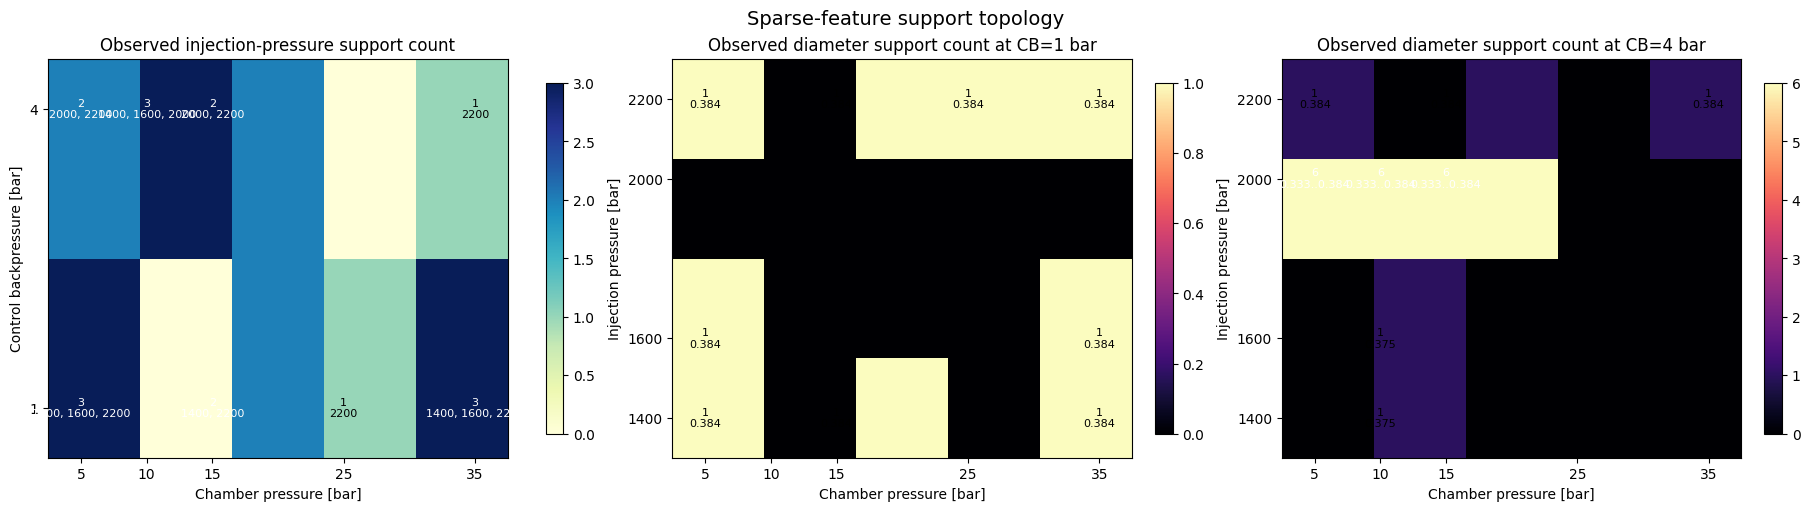

In [21]:
plot_sparse_feature_support_topology(diag_ctx)
plt.show()


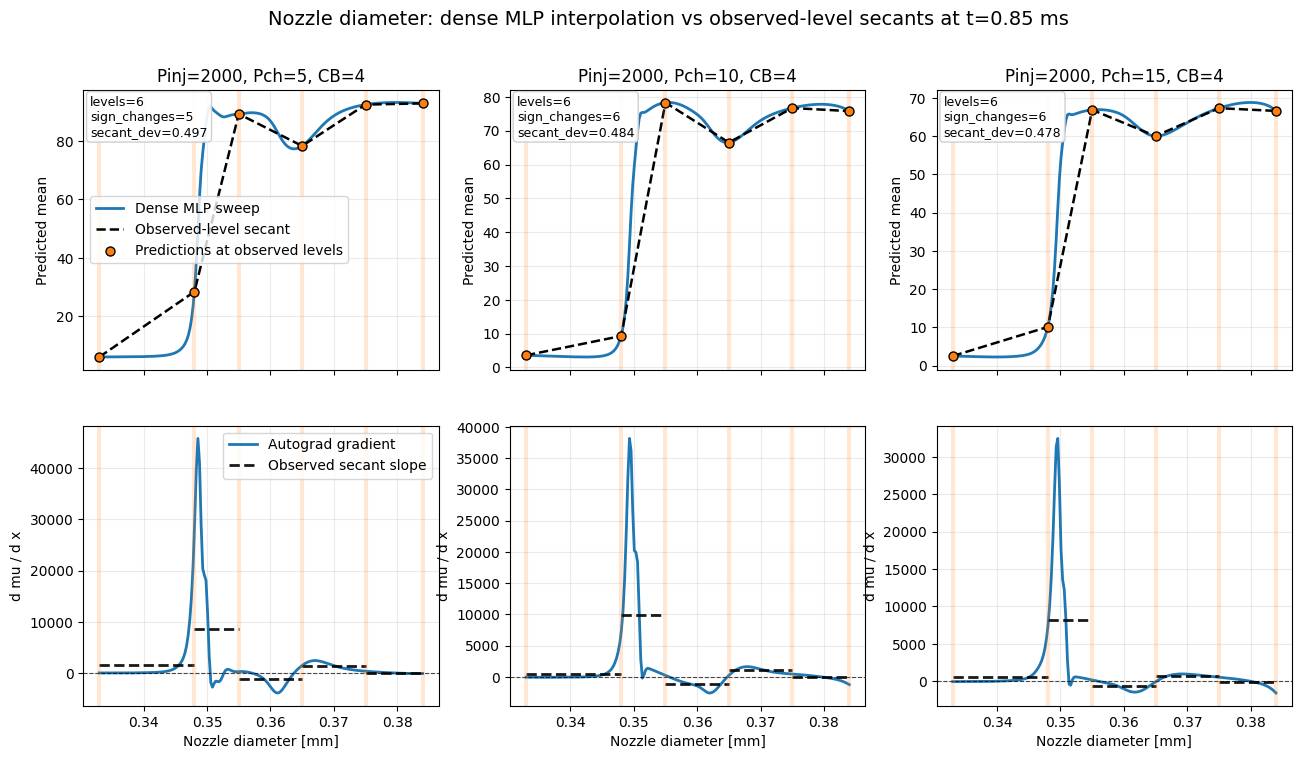

,slice_label,time_ms,anchor_value,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95,curvature_abs_max,mu_range,std_range,support_hull_width,support_mu_span,max_abs_secant_deviation,mean_abs_secant_deviation,max_abs_secant_deviation_ratio,mean_abs_secant_deviation_ratio
0,"Pinj=2000, Pch=5, CB=4",0.85,0.384,6,5,0.2587,111592.4163,0.2387,11636.8350,14057115.0,47123492.0,87.0233,137.5220,0.051,86.7134,43.1270,6.8417,0.4974,0.0789
1,"Pinj=2000, Pch=10, CB=4",0.85,0.384,6,6,0.4627,89180.9828,0.2245,10572.7451,10984914.0,37955168.0,75.2703,77.5156,0.051,74.7196,36.1502,3.9170,0.4838,0.0524
2,"Pinj=2000, Pch=15, CB=4",0.85,0.384,6,6,0.4030,73593.9237,0.2244,8290.6084,8736831.0,34941468.0,66.6109,60.3724,0.051,64.8535,30.9954,3.6079,0.4779,0.0556


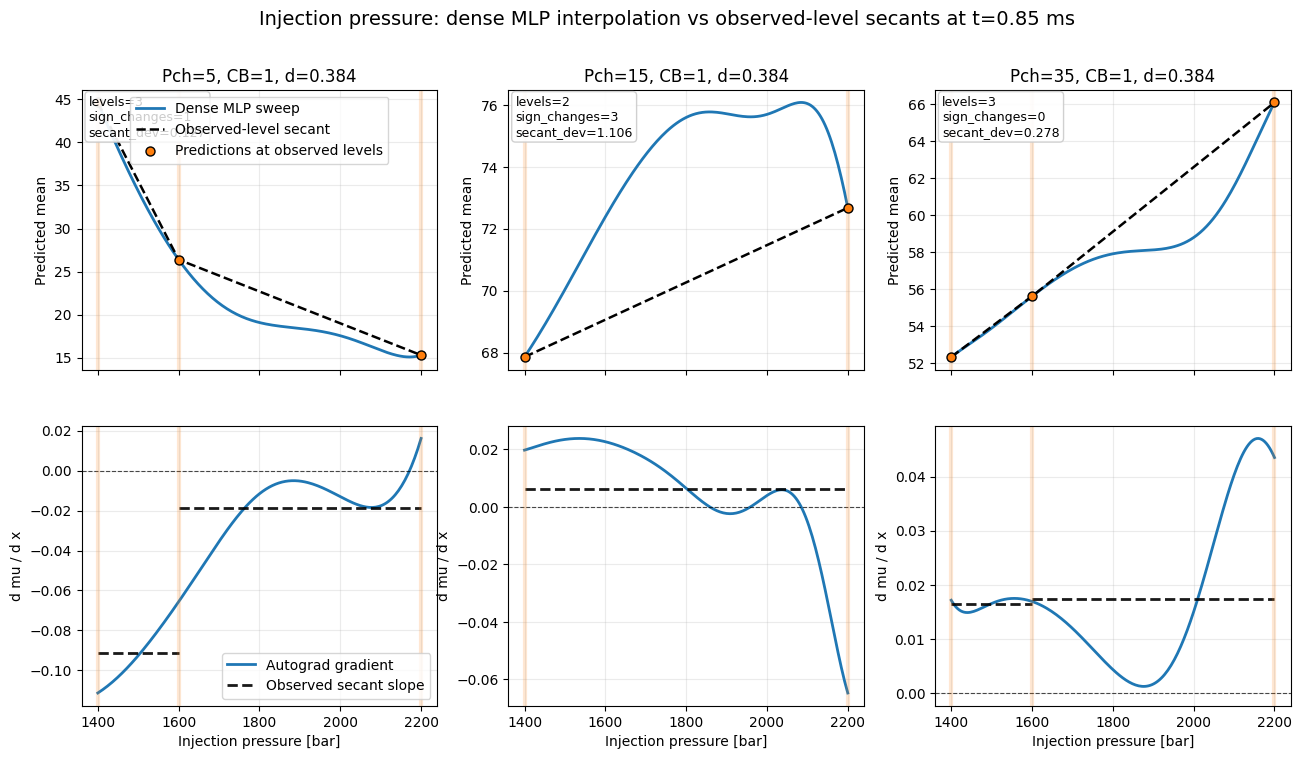

,slice_label,time_ms,anchor_value,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95,curvature_abs_max,mu_range,std_range,support_hull_width,support_mu_span,max_abs_secant_deviation,mean_abs_secant_deviation,max_abs_secant_deviation_ratio,mean_abs_secant_deviation_ratio
0,"Pch=5, CB=1, d=0.384",0.85,2000.0,3,1,0.9602,0.1543,0.0206,0.1052,0.0004,0.0007,29.5511,57.8782,800.0,29.3365,3.7365,1.7649,0.1274,0.0602
1,"Pch=15, CB=1, d=0.384",0.85,2000.0,2,3,0.2687,0.1092,0.0360,0.0398,0.0006,0.0007,8.2211,9.0095,800.0,4.8170,5.3291,3.5709,1.1063,0.7413
2,"Pch=35, CB=1, d=0.384",0.85,2000.0,3,0,0.0000,0.0705,0.0203,0.0461,0.0003,0.0003,13.7515,1.3778,800.0,13.7515,3.8173,1.3785,0.2776,0.1002


In [22]:
diameter_interpolant_fig, diameter_interpolant_metrics_df = plot_sparse_family_interpolants(
    diag_ctx,
    "diameter_mm",
    diameter_family_specs,
    sparse_base_raw,
    time_ms_value=sparse_focus_time_ms,
    expected_sign=+1.0,
    n_points=201,
    fig_title=f"Nozzle diameter: dense MLP interpolation vs observed-level secants at t={sparse_focus_time_ms:.2f} ms",
)
plt.show()
display(diameter_interpolant_metrics_df.round(4))

injection_interpolant_fig, injection_interpolant_metrics_df = plot_sparse_family_interpolants(
    diag_ctx,
    "injection_pressure_bar",
    injection_family_specs,
    sparse_base_raw,
    time_ms_value=sparse_focus_time_ms,
    expected_sign=+1.0,
    n_points=201,
    fig_title=f"Injection pressure: dense MLP interpolation vs observed-level secants at t={sparse_focus_time_ms:.2f} ms",
)
plt.show()
display(injection_interpolant_metrics_df.round(4))


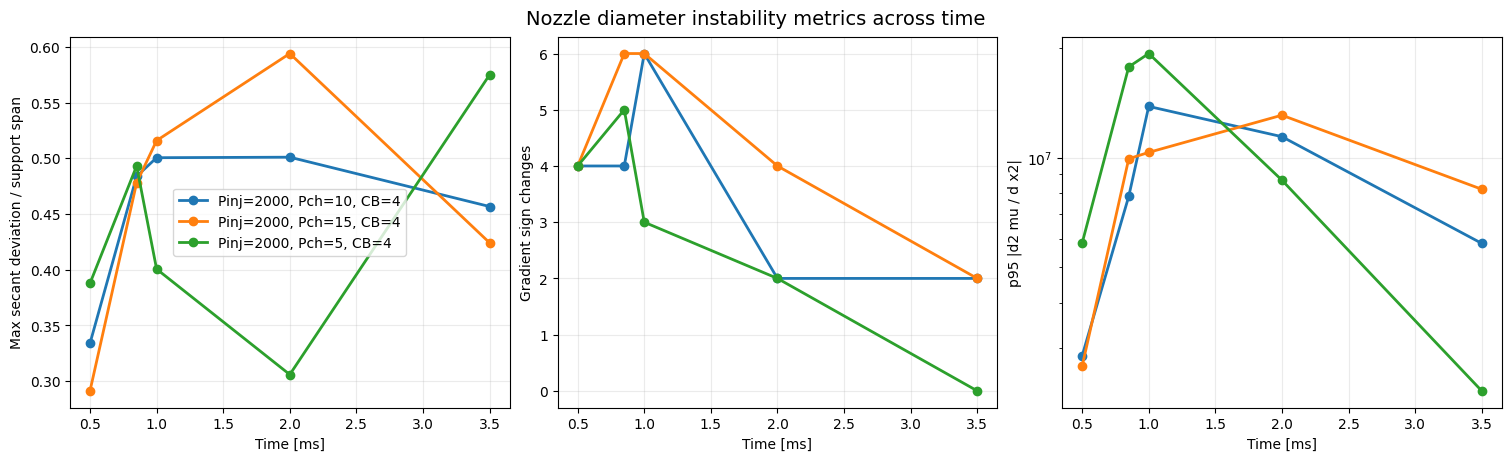

,slice_label,time_ms,anchor_value,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95,curvature_abs_max,mu_range,std_range,support_hull_width,support_mu_span,max_abs_secant_deviation,mean_abs_secant_deviation,max_abs_secant_deviation_ratio,mean_abs_secant_deviation_ratio
0,"Pinj=2000, Pch=5, CB=4",0.50,0.384,6,4,0.3802,42856.8090,0.2217,6913.4277,5832575.5,10165885.00,48.8380,128.8438,0.051,47.6650,18.4851,4.8158,0.3878,0.1010
1,"Pinj=2000, Pch=10, CB=4",0.50,0.384,6,4,0.4215,29988.0049,0.1977,5541.4805,2860743.5,8498135.00,40.7760,65.8509,0.051,40.4075,13.4954,2.8976,0.3340,0.0717
2,"Pinj=2000, Pch=15, CB=4",0.50,0.384,6,4,0.3306,22993.8588,0.1807,5325.4858,2678130.5,4055771.75,35.9166,47.1793,0.051,35.9064,10.4593,2.3737,0.2913,0.0661
3,"Pinj=2000, Pch=5, CB=4",0.85,0.384,6,5,0.2645,107623.1151,0.3850,13138.8457,17759660.0,39241912.00,87.0234,137.5220,0.051,86.7134,42.7587,6.8246,0.4931,0.0787
4,"Pinj=2000, Pch=10, CB=4",0.85,0.384,6,4,0.4628,84327.0685,0.3538,10572.7451,7837043.0,36226744.00,75.2712,77.5155,0.051,74.7196,36.1502,3.9057,0.4838,0.0523
5,"Pinj=2000, Pch=15, CB=4",0.85,0.384,6,6,0.4132,73074.2410,0.3716,8290.6084,9939508.0,33502496.00,66.6078,60.3725,0.051,64.8535,30.9954,3.5961,0.4779,0.0555
6,"Pinj=2000, Pch=5, CB=4",1.00,0.384,6,3,0.3719,115945.4120,0.3966,11362.5293,19321084.0,43978912.00,99.0915,191.4551,0.051,94.0292,37.6677,9.6298,0.4006,0.1024
7,"Pinj=2000, Pch=10, CB=4",1.00,0.384,6,6,0.4215,99605.5020,0.3990,9321.0557,13834741.0,44047448.00,85.5017,82.5856,0.051,84.9237,42.5052,4.6425,0.5005,0.0547
8,"Pinj=2000, Pch=15, CB=4",1.00,0.384,6,6,0.4298,91201.5831,0.4140,9227.7480,10346777.0,41811044.00,75.3439,62.5760,0.051,73.6881,38.0134,4.3452,0.5159,0.0590
9,"Pinj=2000, Pch=5, CB=4",2.00,0.384,6,2,0.2810,58193.3266,0.1964,16341.4736,8681590.0,13095726.00,108.7996,1334.9127,0.051,108.8016,33.2848,5.4607,0.3059,0.0502


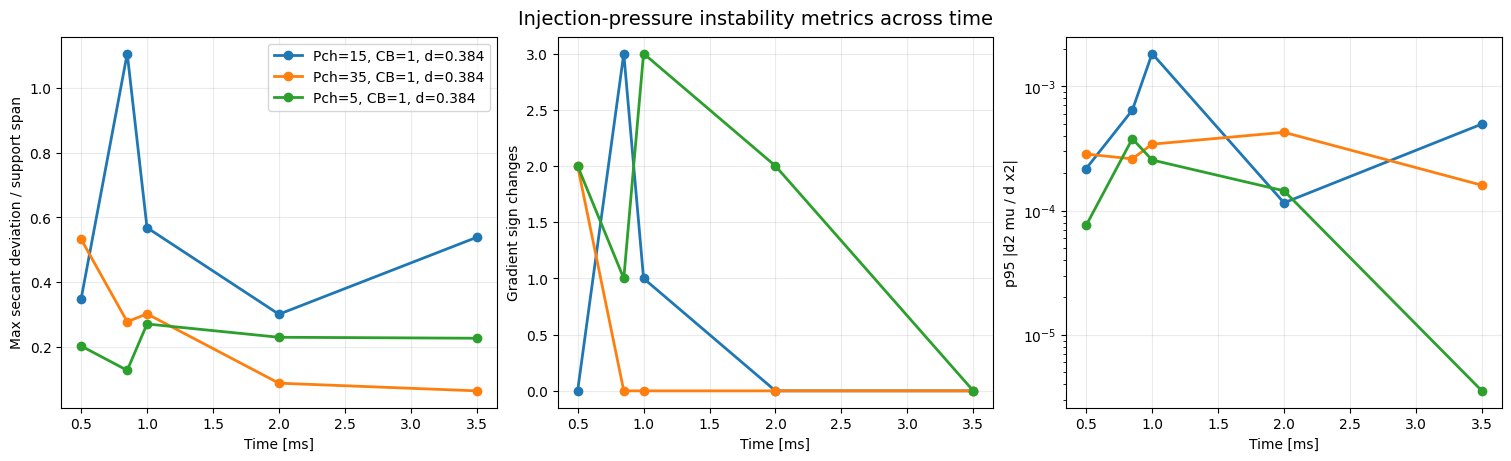

,slice_label,time_ms,anchor_value,support_levels_on_slice,sign_changes,monotonicity_violation_rate,grad_total_variation,grad_total_variation_rel,grad_abs_p95,curvature_abs_p95,curvature_abs_max,mu_range,std_range,support_hull_width,support_mu_span,max_abs_secant_deviation,mean_abs_secant_deviation,max_abs_secant_deviation_ratio,mean_abs_secant_deviation_ratio
0,"Pch=5, CB=1, d=0.384",0.50,2000.0,3,2,0.3223,0.0365,0.0464,0.0186,0.0001,0.0001,3.6860,6.0499,800.0,3.6860,0.7472,0.3260,0.2027,0.0884
1,"Pch=15, CB=1, d=0.384",0.50,2000.0,2,0,0.0000,0.0712,0.0327,0.0537,0.0002,0.0002,14.3177,1.2758,800.0,14.3177,4.9712,2.5398,0.3472,0.1774
2,"Pch=35, CB=1, d=0.384",0.50,2000.0,3,2,0.2893,0.0770,0.0563,0.0434,0.0003,0.0003,7.2010,0.1708,800.0,7.2010,3.8365,1.4960,0.5328,0.2077
3,"Pch=5, CB=1, d=0.384",0.85,2000.0,3,1,0.9587,0.1543,0.0341,0.1052,0.0004,0.0007,29.5503,57.8780,800.0,29.3365,3.7358,1.7587,0.1273,0.0599
4,"Pch=15, CB=1, d=0.384",0.85,2000.0,2,3,0.2727,0.1091,0.0595,0.0398,0.0006,0.0007,8.2205,9.0087,800.0,4.8170,5.3284,3.5588,1.1062,0.7388
5,"Pch=35, CB=1, d=0.384",0.85,2000.0,3,0,0.0000,0.0705,0.0337,0.0461,0.0003,0.0003,13.7515,1.3777,800.0,13.7515,3.8165,1.3738,0.2775,0.0999
6,"Pch=5, CB=1, d=0.384",1.00,2000.0,3,3,0.5537,0.0708,0.0782,0.0255,0.0003,0.0003,3.5174,10.8554,800.0,3.3742,0.9131,0.4201,0.2706,0.1245
7,"Pch=15, CB=1, d=0.384",1.00,2000.0,2,1,0.6860,0.3557,0.0506,0.1801,0.0018,0.0033,41.8431,57.1092,800.0,37.0403,21.0458,13.7816,0.5682,0.3721
8,"Pch=35, CB=1, d=0.384",1.00,2000.0,3,0,0.0000,0.0910,0.0448,0.0475,0.0003,0.0005,13.4041,2.1378,800.0,13.4041,4.0459,1.4058,0.3018,0.1049
9,"Pch=5, CB=1, d=0.384",2.00,2000.0,3,2,0.3554,0.0222,0.0743,0.0118,0.0001,0.0002,1.6726,3.5578,800.0,1.6726,0.3839,0.1192,0.2295,0.0713


In [23]:
diameter_family_time_metrics_df = collect_sparse_family_time_metrics(
    diag_ctx,
    "diameter_mm",
    diameter_family_specs,
    sparse_base_raw,
    sparse_focus_times_ms,
    expected_sign=+1.0,
    n_points=121,
)
injection_family_time_metrics_df = collect_sparse_family_time_metrics(
    diag_ctx,
    "injection_pressure_bar",
    injection_family_specs,
    sparse_base_raw,
    sparse_focus_times_ms,
    expected_sign=+1.0,
    n_points=121,
)

plot_sparse_family_time_metrics(
    diameter_family_time_metrics_df,
    "diameter_mm",
    fig_title="Nozzle diameter instability metrics across time",
)
plt.show()
display(diameter_family_time_metrics_df.round(4))

plot_sparse_family_time_metrics(
    injection_family_time_metrics_df,
    "injection_pressure_bar",
    fig_title="Injection-pressure instability metrics across time",
)
plt.show()
display(injection_family_time_metrics_df.round(4))
